In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from tqdm import tqdm
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid

2025-11-27 15:11:06.096212: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 15:11:11.616775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-27 15:11:13.719215: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-27 15:11:14.488903: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-27 15:11:18.581645: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def load_real_samples(scale=False):
    X = np.load('stanford_dogs_64x64.npy')[:20000]  # or remove slicing to load all
    if scale:
        X = (X - 127.5) * 2
    return X / 255.0

dataset = load_real_samples()

In [3]:
N_layers = 4

In [4]:
# We will use this function to display the output of our models throughout this notebook
def grid_plot(images, epoch='', name='', n=3, save=False, scale=False):
    if scale:
        images = (images + 1) / 2.0
    for index in range(n * n):
        plt.subplot(n, n, 1 + index)
        plt.axis('off')
        plt.imshow(images[index])
    fig = plt.gcf()
    fig.suptitle(name + '  '+ str(epoch), fontsize=14)
    if save:
        plt.savefig(f'Graphs/{name + '  '+ str(epoch)}.png')
        
    plt.show()
    plt.close()

In [5]:
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Conv2DTranspose, Reshape

def build_conv_net(in_shape, out_shape, n_downsampling_layers=4, filters=128, out_activation='sigmoid'):
    """
    Build a basic convolutional network
    """
    default_args=dict(kernel_size=(3,3), strides=(2,2), padding='same', activation='relu')

    input = tf.keras.Input(shape=in_shape)
    x = Conv2D(filters=filters, name='enc_input', **default_args)(input) #** is the unpacking argument

    for _ in range(n_downsampling_layers): # _ if we dont care about the varible itself
        x = Conv2D(**default_args, filters=filters)(x)

    x = Flatten()(x)
    x = Dense(out_shape, activation=out_activation, name='enc_output')(x) # out_shape gives the shape of the latent space

    model = tf.keras.Model(inputs=input, outputs=x, name='Encoder')

    model.summary()
    return model


def build_deconv_net(latent_dim, n_upsampling_layers=4, filters=128, activation_out='sigmoid'):
    """
    Build a deconvolutional network for decoding/upscaling latent vectors

    When building the deconvolutional architecture, usually it is best to use the same layer sizes that
    were used in the downsampling network and the Conv2DTranspose layers are used instead of Conv2D layers.
    Using identical layers and hyperparameters ensures that the dimensionality of our output matches the
    shape of our input images.
    """
    input = tf.keras.Input(shape=(latent_dim,))
    x = Dense(4 * 4 * 64, input_dim=latent_dim, name='dec_input')(input)
    x = Reshape((4, 4, 64))(x) # This matches the output size of the downsampling architecture

    default_args=dict(kernel_size=(3,3), strides=(2,2), padding='same', activation='relu')

    for i in range(n_upsampling_layers):
        x = Conv2DTranspose(filters=filters, **default_args)(x) # reverse of a Conv layer, takes 1 input and maps kernel to output, addind where overlap

    # This last convolutional layer converts back to 3 channel RGB image
    x = Conv2D(filters=3, kernel_size=(3,3), padding='same', activation=activation_out, name='dec_output')(x)

    model = tf.keras.Model(inputs=input, outputs=x, name='Decoder')
    model.summary()
    return model

In [6]:
class Sampling(tf.keras.layers.Layer):
    """
    Custom layer for the variational autoencoder
    It takes two vectors as input - one for means and other for variances of the latent variables described by a multimodal gaussian
    Its output is a latent vector randomly sampled from this distribution
    """
    def call(self, inputs):
        z_mean, z_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim)) # e for each of the pixels 64x64x3 in each image
        return z_mean + tf.exp(0.5 * z_var) * epsilon # log variance here

def build_vae(data_shape, latent_dim, filters=128):

    # Building the encoder - starts with a simple downsampling convolutional network
    encoder = build_conv_net(data_shape, latent_dim*2, filters=filters) # 2 since have both mu and sigma

    # Adding special sampling layer that uses the reparametrization trick
    z_mean = Dense(latent_dim)(encoder.output)
    z_var = Dense(latent_dim)(encoder.output)
    z = Sampling()([z_mean, z_var]) # z is our latent varible vector

    # Connecting the two encoder parts
    encoder = tf.keras.Model(inputs=encoder.input, outputs=z)

    # Defining the decoder which is a regular upsampling deconvolutional network
    decoder = build_deconv_net(latent_dim, activation_out='sigmoid', filters=filters)
    vae = tf.keras.Model(inputs=encoder.input, outputs=decoder(z))

    # Define a custom layer for the KL loss calculation
    class KLLossLayer(tf.keras.layers.Layer):
        def call(self, inputs):
            z_mean, z_var = inputs
            kl_loss = -0.5 * tf.reduce_sum(z_var - tf.square(z_mean) - tf.exp(z_var) + 1)
            # Add the KL loss to the model's losses
            self.add_loss(kl_loss / tf.cast(tf.keras.backend.prod(data_shape), tf.float32))
            return inputs  # Pass through the inputs unchanged

    # Apply the custom layer to z_mean and z_var
    _, _ = KLLossLayer()([z_mean, z_var])

    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='binary_crossentropy')

    return encoder, decoder, vae

Model: "Encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 enc_input (Conv2D)          (None, 32, 32, 64)        1792      
                                                                 
 conv2d (Conv2D)             (None, 16, 16, 64)        36928     
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 64)          36928     
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 2, 2, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 256)               0   

I0000 00:00:1764252776.695093  125609 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-11-27 15:13:01.570658: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "Decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64)]              0         
                                                                 
 dec_input (Dense)           (None, 1024)              66560     
                                                                 
 reshape (Reshape)           (None, 4, 4, 64)          0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 64)          36928     
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 16, 16, 64)        36928     
 Transpose)                                                      
                                                                 
 conv2d_transpose_2 (Conv2D  (None, 32, 32, 64)        3692

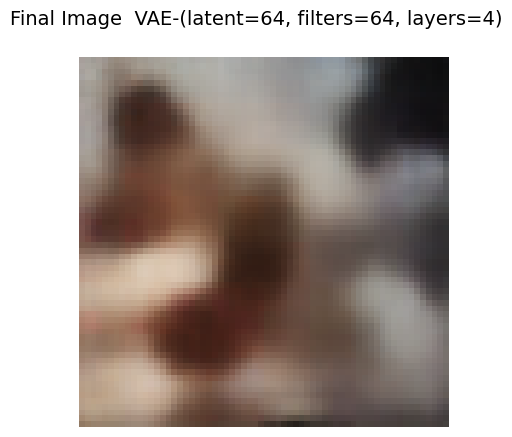

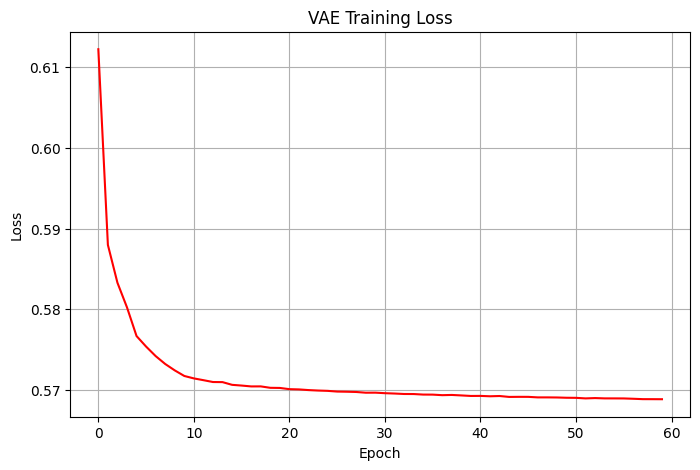

In [7]:
# Training the VAE model

latent_dim = 64
n_f = 64
b_s = 16
N_layers = 4
n_epochs = 60
saveM= True

encoder, decoder, vae = build_vae(dataset.shape[1:], latent_dim, filters=n_f) # three seperate ones since want to be able to input latent varibles
Title = f"VAE-(latent={latent_dim}, filters={n_f}, layers={N_layers})"
history = {'VAE_loss': []}
i=0
for epoch in range(n_epochs):

    epoch_VAE_loss = 0.0

    
    h = vae.fit(x=dataset, y=dataset, epochs=1, batch_size=b_s)
    loss_value = h.history['loss'][0]   # reconstruction loss + KL
    history['VAE_loss'].append(loss_value)


    i+=1 
    if i == n_epochs:
        coefficient = 3                                # You can tweak this coefficient to increase/decrease the std of the sampled vectors
        latent_vectors = np.random.randn(1, latent_dim) # Generate 9 random points in the latent space
        images = decoder(latent_vectors / coefficient)  # Feed the vectors scaled by the coefficient to the model
        grid_plot(images, epoch=Title, name='Final Image', n=1, save=True)

    if saveM==True:
        decoder.save(f"Models/{Title}.keras")

    tf.keras.backend.clear_session()

plt.figure(figsize=(8,5))
plt.plot(history['VAE_loss'], 'r', label='VAE Loss')
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(f"Graphs/{Title}.png")
plt.show()

In [2]:
#!jupyter nbconvert --to python VAE_Final-4.ipynb

[NbConvertApp] Converting notebook VAE_Final-4.ipynb to python
[NbConvertApp] Writing 6923 bytes to VAE_Final-4.py
